# **ETL of League of Legends Ranked Matches**

## Objectives

* Clean Data taken from Kaggle relating to League of Legends Ranked Matches

## Inputs

* RawData taken from Kaggle

## Outputs

* CleanData


---

# Change working directory

* We are assuming you will store the notebooks in a subfolder, therefore when running the notebook in the editor, you will need to change the working directory

We need to change the working directory from its current folder to its parent folder
* We access the current directory with os.getcwd()

In [2]:
import os
current_dir = os.getcwd()
current_dir

'd:\\Coding Cooler Dump\\Credit Card Customers Analysis\\jupyter_notebooks'

We want to make the parent of the current directory the new current directory
* os.path.dirname() gets the parent directory
* os.chir() defines the new current directory

In [3]:
os.chdir(os.path.dirname(current_dir))
print("You set a new current directory")

You set a new current directory


Confirm the new current directory

In [4]:
current_dir = os.getcwd()
current_dir

'd:\\Coding Cooler Dump\\Credit Card Customers Analysis'

# Preparation for Data Cleaning

Importing Libraries that will be used in data cleaning

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Loading the Data Set

In [6]:
# Loading the dataset as df
df = pd.read_csv("Dataset/RawData/Games.csv")

# Allowing all columns to be displayed at once.
pd.set_option('display.max_columns', None)
# Displaying the first 5 rows of the dataset, to confirm it has been loaded.
df.head()

,gameId,creationTime,gameDuration,seasonId,winner,firstBlood,firstTower,firstInhibitor,firstBaron,firstDragon,firstRiftHerald,t1_champ1id,t1_champ1_sum1,t1_champ1_sum2,t1_champ2id,t1_champ2_sum1,t1_champ2_sum2,t1_champ3id,t1_champ3_sum1,t1_champ3_sum2,t1_champ4id,t1_champ4_sum1,t1_champ4_sum2,t1_champ5id,t1_champ5_sum1,t1_champ5_sum2,t1_towerKills,t1_inhibitorKills,t1_baronKills,t1_dragonKills,t1_riftHeraldKills,t1_ban1,t1_ban2,t1_ban3,t1_ban4,t1_ban5,t2_champ1id,t2_champ1_sum1,t2_champ1_sum2,t2_champ2id,t2_champ2_sum1,t2_champ2_sum2,t2_champ3id,t2_champ3_sum1,t2_champ3_sum2,t2_champ4id,t2_champ4_sum1,t2_champ4_sum2,t2_champ5id,t2_champ5_sum1,t2_champ5_sum2,t2_towerKills,t2_inhibitorKills,t2_baronKills,t2_dragonKills,t2_riftHeraldKills,t2_ban1,t2_ban2,t2_ban3,t2_ban4,t2_ban5
0,3326086514,1504279457970,1949,9,1,2,1,1,1,1,2,8,12,4,432,3,4,96,4,7,11,11,6,112,4,14,11,1,2,3,0,92,40,69,119,141,104,11,4,498,4,7,122,6,4,238,14,4,412,4,3,5,0,0,1,1,114,67,43,16,51
1,3229566029,1497848803862,1851,9,1,1,1,1,0,1,1,119,7,4,39,12,4,76,4,3,10,4,14,35,4,11,10,4,0,2,1,51,122,17,498,19,54,4,12,25,4,14,120,11,4,157,4,14,92,4,7,2,0,0,0,0,11,67,238,51,420
2,3327363504,1504360103310,1493,9,1,2,1,1,1,2,0,18,4,7,141,11,4,267,3,4,68,4,12,38,12,4,8,1,1,1,0,117,40,29,16,53,69,4,7,412,14,4,126,4,12,24,4,11,22,7,4,2,0,0,1,0,157,238,121,57,28
3,3326856598,1504348503996,1758,9,1,1,1,1,1,1,0,57,4,12,63,4,14,29,4,7,61,4,1,36,11,4,9,2,1,2,0,238,67,516,114,31,90,14,4,19,11,4,412,4,3,92,4,14,22,4,7,0,0,0,0,0,164,18,141,40,51
4,3330080762,1504554410899,2094,9,1,2,1,1,1,1,0,19,4,12,29,11,4,40,4,3,119,4,7,134,7,4,9,2,1,3,0,90,64,412,25,31,37,3,4,59,4,12,141,11,4,38,4,12,51,4,7,3,0,0,1,0,86,11,201,122,18


---

# Removing Duplicates

Prior to removing columns, I first want to remove duplicate rows. Within this dataset, a gameId is provided, which functions as a unique key for each match that occurs. Due to this, it is only necessary to seek duplicate values within the gameId column.

In [7]:
# Creating a variable with the number of duplicates within the dataset, for later comparison.
duplicates = df.duplicated('gameId')
# Dropping the duplicates from the dataset
df.drop_duplicates(subset='gameId', inplace=True)
# Confirming the number of duplicates dropped from the dataset.
print(f"duplicates dropped: {duplicates.sum()}")

duplicates dropped: 437


According to the EDA, there was a total of 437 Duplicates to remove. This is reflected in the above code, which suggests that 437 duplicates were dropped. We may now assume there are no remaining duplicates in the data.

---

# Removing Redundant Columns

Columns that hold little to no value will be dropped. Included is every instance of "sum1" and "sum2", as well as ban choices, seasonId and creation time.

Since gameId has already been used to remove duplicated rows, there is no need for it anymore. For this reason, It will also be dropped.

Currently, I am hesistant to remove additional columns, as I may find value in them, though strictly speaking, if I were purely seeking to predict a winner prior to the game starting, most columns, such as game duration should be dropped - For the time being, they have been dropped, though if I find it necessary, they will be returned.

In [8]:
dfclean = df.drop(columns=['t1_ban1', 't1_ban2', 't1_ban3', 't1_ban4', 't1_ban5', 't2_ban1', 't2_ban2', 't2_ban3', 't2_ban4', 't2_ban5','t1_champ1_sum1', 't1_champ1_sum2', 't1_champ2_sum1', 't1_champ2_sum2', 't1_champ3_sum1', 't1_champ3_sum2', 't1_champ4_sum1', 't1_champ4_sum2', 't1_champ5_sum1', 't1_champ5_sum2', 't2_champ1_sum1', 't2_champ1_sum2', 't2_champ2_sum1', 't2_champ2_sum2', 't2_champ3_sum1', 't2_champ3_sum2', 't2_champ4_sum1', 't2_champ4_sum2', 't2_champ5_sum1', 't2_champ5_sum2', 'seasonId', 'creationTime', 'gameDuration','gameId', 'firstBlood', 'firstTower', 'firstInhibitor', 'firstBaron', 'firstDragon', 'firstRiftHerald', 't1_towerKills', 't1_inhibitorKills', 't1_baronKills', 't1_dragonKills', 't1_riftHeraldKills', 't2_towerKills', 't2_inhibitorKills', 't2_baronKills', 't2_dragonKills', 't2_riftHeraldKills'])
dfclean.head()

,winner,t1_champ1id,t1_champ2id,t1_champ3id,t1_champ4id,t1_champ5id,t2_champ1id,t2_champ2id,t2_champ3id,t2_champ4id,t2_champ5id
0,1,8,432,96,11,112,104,498,122,238,412
1,1,119,39,76,10,35,54,25,120,157,92
2,1,18,141,267,68,38,69,412,126,24,22
3,1,57,63,29,61,36,90,19,412,92,22
4,1,19,29,40,119,134,37,59,141,38,51


---

# Creating New Columns

Using the remaining Columns, it is possible to create new columns, such as the percentage win rate of each character.

For this step, I employed the help of co-pilot, and slightly polished what was created. The code below places champId along the winner of each match, and converts the given data into a value reflecting the number of times a certain champId appears on the team declared winner each game.

In [23]:
# Find winner column and champion ID columns
winner_col_candidates = [
    col for col in ["winner"]
    if col in dfclean.columns
]
winner_col = winner_col_candidates[0] if winner_col_candidates else None

# Find champion ID columns
champ_cols = [
    col for col in dfclean.columns
    if col.endswith('id') and col.startswith('t') and any(char.isdigit() for char in col)
]

champ_win_records = []
for champ_col in champ_cols:
    side = 1 if champ_col.startswith("t1_") else 2

    temp = dfclean[[champ_col, winner_col]].copy()
    temp = temp.rename(columns={champ_col: "champId"})
    
    # Champion wins if their team matches the winner side (1 or 2)
    temp["champ_win"] = (temp[winner_col] == side).astype(int)
    champ_win_records.append(temp[["champId", "champ_win"]])

champ_results = pd.concat(champ_win_records, ignore_index=True)
champ_winrate = champ_results.groupby("champId")["champ_win"].mean().mul(100)

# Add per-column mapped win-rate percentages to dfclean
for champ_col in champ_cols:
    dfclean[f"{champ_col}_winrate"] = dfclean[champ_col].map(champ_winrate).round(2)

# Preview only the new columns
new_winrate_cols = [f"{col}_winrate" for col in champ_cols]
dfclean[new_winrate_cols].head()

,t1_champ1id_winrate,t1_champ2id_winrate,t1_champ3id_winrate,t1_champ4id_winrate,t1_champ5id_winrate,t2_champ1id_winrate,t2_champ2id_winrate,t2_champ3id_winrate,t2_champ4id_winrate,t2_champ5id_winrate
0,49.01,47.85,50.49,50.97,47.48,47.46,49.84,51.54,49.31,47.26
1,50.18,50.60,46.21,50.83,49.56,50.02,47.99,50.76,50.18,49.78
2,51.70,48.70,51.72,49.17,49.24,48.87,47.26,50.51,50.59,47.71
3,51.79,51.45,52.78,50.25,50.00,53.02,51.61,47.26,49.78,47.71
4,51.61,52.78,55.52,50.18,46.64,54.23,52.34,48.70,49.24,46.94


After this step, I decided to view the first few rows of dfclean to ensure the new columns have been correctly added. Following this, they may be used in visualisations.

In [14]:
dfclean.head()

,winner,t1_champ1id,t1_champ2id,t1_champ3id,t1_champ4id,t1_champ5id,t2_champ1id,t2_champ2id,t2_champ3id,t2_champ4id,t2_champ5id,t1_champ1id_winrate,t1_champ2id_winrate,t1_champ3id_winrate,t1_champ4id_winrate,t1_champ5id_winrate,t2_champ1id_winrate,t2_champ2id_winrate,t2_champ3id_winrate,t2_champ4id_winrate,t2_champ5id_winrate
0,1,8,432,96,11,112,104,498,122,238,412,49.01,47.85,50.49,50.97,47.48,47.46,49.84,51.54,49.31,47.26
1,1,119,39,76,10,35,54,25,120,157,92,50.18,50.60,46.21,50.83,49.56,50.02,47.99,50.76,50.18,49.78
2,1,18,141,267,68,38,69,412,126,24,22,51.70,48.70,51.72,49.17,49.24,48.87,47.26,50.51,50.59,47.71
3,1,57,63,29,61,36,90,19,412,92,22,51.79,51.45,52.78,50.25,50.00,53.02,51.61,47.26,49.78,47.71
4,1,19,29,40,119,134,37,59,141,38,51,51.61,52.78,55.52,50.18,46.64,54.23,52.34,48.70,49.24,46.94


After creating the winrate columns I decided it may also be of value to create pickrate columns - these would display the number of times each character has been selected, as percentate of the total matches in the dataset.

Similar to the win rate percentages, I employed Co-Pilot to aid in the coding, which I then polished slightly.

One issue I encountered with this code is incorrect numbers being provided, with winrate being presented as 10 times as large as it should have been, for all champions.

In [18]:
# Build pick-rate columns for each champId column
champ_cols = [
    col for col in dfclean.columns
    if pd.Series(col).str.match(r"^t[12]_champ[1-5]id$").iloc[0]
]

# Pick rate = % of matches where champion appears
match_presence = pd.DataFrame({"champId": pd.unique(dfclean[champ_cols].to_numpy().ravel())})
champ_pickrate = (
    match_presence["champId"]
    .map(lambda champ: dfclean[champ_cols].eq(champ).any(axis=1).mean() * 10)
)
champ_pickrate = pd.Series(champ_pickrate.values, index=match_presence["champId"])

# Add per-column mapped pick-rate percentages to dfclean
for champ_col in champ_cols:
    dfclean[f"{champ_col}_pickrate"] = dfclean[champ_col].map(champ_pickrate).round(2)

new_pickrate_cols = [f"{col}_pickrate" for col in champ_cols]
dfclean[new_pickrate_cols].head()

,t1_champ1id_pickrate,t1_champ2id_pickrate,t1_champ3id_pickrate,t1_champ4id_pickrate,t1_champ5id_pickrate,t2_champ1id_pickrate,t2_champ2id_pickrate,t2_champ3id_pickrate,t2_champ4id_pickrate,t2_champ5id_pickrate
0,0.62,0.72,0.63,1.15,0.34,0.28,1.52,0.76,1.25,2.52
1,0.99,0.44,0.33,0.39,0.50,0.49,1.15,0.39,1.53,1.18
2,2.52,1.91,0.91,0.31,0.59,0.54,2.52,0.62,1.29,1.05
3,0.84,0.75,1.72,1.27,0.30,0.73,1.14,2.52,1.18,1.05
4,1.14,1.72,1.69,0.99,0.73,1.05,1.17,1.91,0.59,1.32


After generating the new columns, I wanted to ensure they were correctly appended onto the dataset, so I used dfclean.head()

In [19]:
dfclean.head()

,winner,t1_champ1id,t1_champ2id,t1_champ3id,t1_champ4id,t1_champ5id,t2_champ1id,t2_champ2id,t2_champ3id,t2_champ4id,t2_champ5id,t1_champ1id_winrate,t1_champ2id_winrate,t1_champ3id_winrate,t1_champ4id_winrate,t1_champ5id_winrate,t2_champ1id_winrate,t2_champ2id_winrate,t2_champ3id_winrate,t2_champ4id_winrate,t2_champ5id_winrate,t1_champ1id_pickrate,t1_champ2id_pickrate,t1_champ3id_pickrate,t1_champ4id_pickrate,t1_champ5id_pickrate,t2_champ1id_pickrate,t2_champ2id_pickrate,t2_champ3id_pickrate,t2_champ4id_pickrate,t2_champ5id_pickrate
0,1,8,432,96,11,112,104,498,122,238,412,49.01,47.85,50.49,50.97,47.48,47.46,49.84,51.54,49.31,47.26,0.62,0.72,0.63,1.15,0.34,0.28,1.52,0.76,1.25,2.52
1,1,119,39,76,10,35,54,25,120,157,92,50.18,50.60,46.21,50.83,49.56,50.02,47.99,50.76,50.18,49.78,0.99,0.44,0.33,0.39,0.50,0.49,1.15,0.39,1.53,1.18
2,1,18,141,267,68,38,69,412,126,24,22,51.70,48.70,51.72,49.17,49.24,48.87,47.26,50.51,50.59,47.71,2.52,1.91,0.91,0.31,0.59,0.54,2.52,0.62,1.29,1.05
3,1,57,63,29,61,36,90,19,412,92,22,51.79,51.45,52.78,50.25,50.00,53.02,51.61,47.26,49.78,47.71,0.84,0.75,1.72,1.27,0.30,0.73,1.14,2.52,1.18,1.05
4,1,19,29,40,119,134,37,59,141,38,51,51.61,52.78,55.52,50.18,46.64,54.23,52.34,48.70,49.24,46.94,1.14,1.72,1.69,0.99,0.73,1.05,1.17,1.91,0.59,1.32


---

# Visualisations

In this section, I would like to briefly display the data provided by the new columns created.

One key visual I wanted to create is one that compares winrate to pick rate for each character. This is a visualisation I have previously seen as a method for developers for other games to provide explanation for updates made to a game in question - this will be explained following the visualisation.

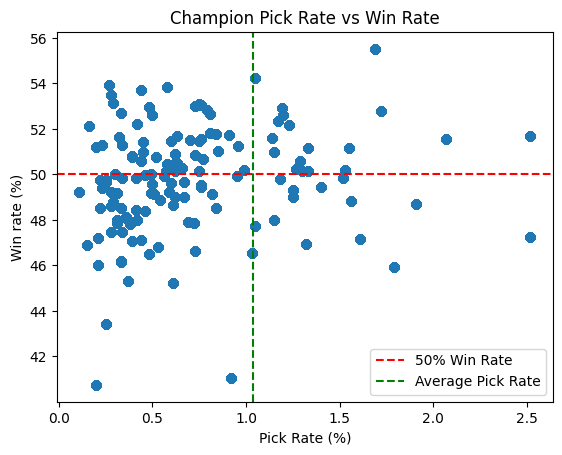

In [21]:
# Creating variables to use as x and y values
winrate_all = dfclean[new_winrate_cols]
pickrate_all = dfclean[new_pickrate_cols]

# Calculating average pick rate in order to form intersection lines.
avg_pickrate = pickrate_all.values.flatten().mean()

# Plotting the graph
plt.scatter(y=winrate_all.values.flatten(), x=pickrate_all.values.flatten())
plt.xlabel("Pick Rate (%)")
plt.ylabel("Win rate (%)")
plt.title("Champion Pick Rate vs Win Rate")
# Creating the intersection lines
plt.axhline(y=50, color='r', linestyle='--', label='50% Win Rate', linewidth=1.5)
plt.axvline(x=avg_pickrate, color='g', linestyle='--', label='Average Pick Rate', linewidth=1.5)
# Ensuring titles for intersection lines are displayed
plt.legend()
plt.show()

In this form, this visualisation is rather unhelpful, as titles for champions cannot be provided, due to the amount of champions involved. This visualisation simply serves to provide a graphic displaying the new columns.

This plot provides a way to identify champions that are too strong, too popular, and vise versa - the two intersection lines show an ideal area for champions to be placed along, since a 50% winrate indicates that a given champion is not too strong or weak, while fitting into the average pick rate means it is not too popular or too ignored.

---

# Saving the data

Here, I will now push this Clean Data into "CleanedData" as a .csv file

In [22]:
dfclean.to_csv("Dataset/CleanedData/cleanData.csv", index=False)